# The below code was written by gemini
This just takes two arrays, graphs the box plot and calculates the p values for statistical significance

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
def analyze_cv_results(baseline_r2, engineered_r2, model_a_name="Baseline", model_b_name="Engineered"):
    baseline_r2 = np.array(baseline_r2)
    engineered_r2 = np.array(engineered_r2)
    
    t_stat, p_value = stats.ttest_rel(baseline_r2, engineered_r2)
    
    print("-" * 40)
    print(f"Statistical Analysis: {model_a_name} vs {model_b_name}")
    print("-" * 40)
    print(f"{model_a_name} Mean R2: {baseline_r2.mean():.4f} (std: {baseline_r2.std():.4f})")
    print(f"{model_b_name} Mean R2: {engineered_r2.mean():.4f} (std: {engineered_r2.std():.4f})")
    print(f"Paired t-test p-value: {p_value:.4g}")
    print("-" * 40)

    plt.figure(figsize=(7, 6))
    
    box_plot_data = [baseline_r2, engineered_r2]
    bp = plt.boxplot(box_plot_data, tick_labels=[model_a_name, model_b_name], patch_artist=True, widths=0.5)
    
    colors = ['white', '#dddddd']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_edgecolor('black')
        patch.set_linewidth(1.5)
    
    for median in bp['medians']:
        median.set(color='black', linewidth=2)
        
    for whisker in bp['whiskers']:
        whisker.set(color='black', linewidth=1.5, linestyle='--')
    for cap in bp['caps']:
        cap.set(color='black', linewidth=1.5)
        
    plt.title('Cross-Validation Stability ($R^2$ Scores)', fontsize=14, pad=20)
    plt.ylabel('$R^2$ Score', fontsize=12)
    plt.grid(axis='y', linestyle=':', alpha=0.6, color='black') # Black dotted grid
    
    plt.tight_layout()
    plt.show()

----------------------------------------
Statistical Analysis: RFR vs Transformer
----------------------------------------
RFR Mean R2: 0.1108 (std: 0.0305)
Transformer Mean R2: 0.1982 (std: 0.0340)
Paired t-test p-value: 0.02645
----------------------------------------


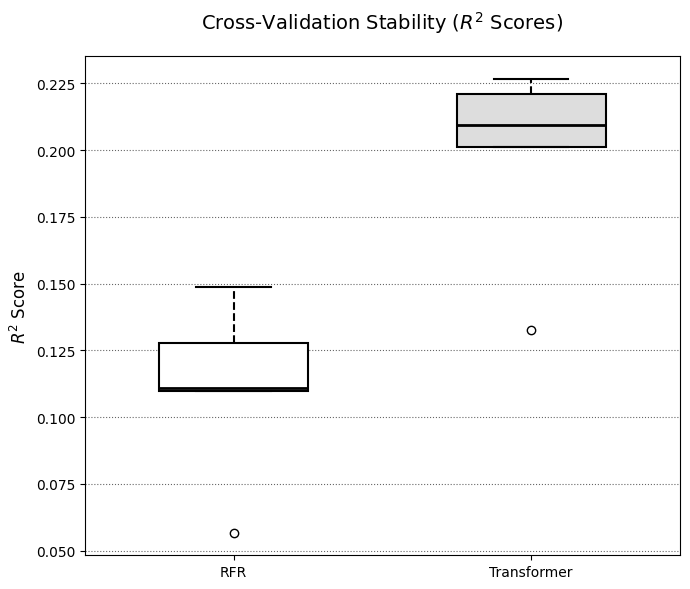

In [14]:
baseline_scores = [
    0.11104292127555204,
    0.1487465284678866,
    0.12776062951301492,
    0.05677827529981616,
    0.10962971280562461,
]
history_added_scores = [
    0.20947080850601196,
    0.22657865285873413,
    0.13258206844329834,
    0.22100281715393066,
    0.2012118697166443,
]

analyze_cv_results(
    baseline_r2=baseline_scores,
    engineered_r2=history_added_scores,
    model_a_name="RFR",
    model_b_name="Transformer",
)